In [1]:
from calorine.calculators import CPUNEP
from ase.io import read, write
from ase.io.netcdftrajectory import write_netcdftrajectory, NetCDFTrajectory
from ase.io.trajectory import Trajectory
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from ase.visualize import view
from ase.md.langevin import Langevin
from ase.md.nptberendsen import NPTBerendsen, Inhomogeneous_NPTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase import units
import matplotlib.pyplot as plt
import numpy as np
import MDAnalysis as mda

/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
cif = "mp-2998_BaTiO3.cif"
atoms = read(cif)
Nuc = 4

atoms.calc = CPUNEP("nep.txt")

cf = FrechetCellFilter(atoms)
relax = BFGS(cf, logfile=None)
relax.run(fmax=0.001)
atoms = atoms.repeat((Nuc,Nuc,Nuc))
atoms.calc = CPUNEP("nep.txt")

In [76]:
#!rm md.traj md.log md.xyz md.exyz 'md{int(T)}.nc' 'md{int(T)}.log'

In [19]:
T = 50.
dump = 10 # Dump after dump number of steps
dt = 1.0

MaxwellBoltzmannDistribution(atoms, temperature_K=T)
Stationary(atoms)

# Check the initialized temperature
print("Initialized Temperature:", atoms.get_temperature(), "K")

dyn_nvt = Langevin(
    atoms,
    timestep=dt * units.fs,
    temperature_K=T,
    friction=0.01 / units.fs,
    logfile=f'md{int(T)}.log')

dyn = Inhomogeneous_NPTBerendsen(atoms,
                   timestep=dt * units.fs,
                   temperature_K=T,
                   taut=100 * units.fs, pressure_au=1.01325 * units.bar,
                   taup=1000 * units.fs, compressibility_au=1e-6 / units.bar,
                   logfile=f'md{int(T)}.log')

def write_xyz():
    #write(f'md{int(T)}.xyz', atoms, append=True, format='extxyz')
    #write_netcdftrajectory(f'md{int(T)}.nc', atoms, mode='a')

    #write(f'md{int(T)}.nc', atoms, format="netcdftrajectory")
    with NetCDFTrajectory(f'md{int(T)}.nc', mode='a') as traj:
        traj.write(atoms)

dyn.attach(write_xyz, interval=dump)
dyn.run(5e4)
#dyn.run(5e3)

Initialized Temperature: 44.805884396875996 K


True

In [69]:
T = 50.

Text(0, 0.5, 'Temperature (K)')

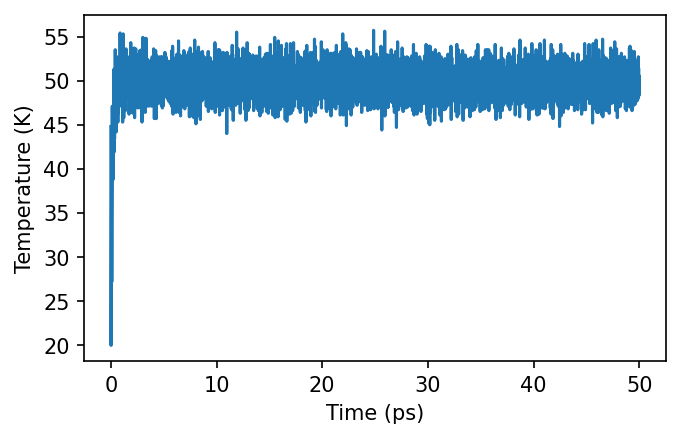

In [70]:
thermo = np.loadtxt(f'md{int(T)}.log', skiprows=1)

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
ax.plot(thermo[:,0], thermo[:,-1])
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Temperature (K)")

In [71]:
view(read(f'md{int(T)}.nc', index=":"))

<Popen: returncode: None args: ['/Users/work/miniconda3/envs/dft-stuff/bin/p...>

In [72]:
mdtraj = read(f'md{int(T)}.nc', index=":")

# Shift back in to unit cell from supercell

In [6]:
from ase.io import iread

In [27]:
for atom in iread('results/ALnep/iteration_1/md/temp/run_001/dump.xyz', index="::100"):
    print(atom.get_positions(), flush=True)

[[3.91903700e-02 2.89578800e-02 1.10125500e-02]
 [3.99449044e+00 2.79764400e-02 7.88108755e+00]
 [1.34241800e-02 3.96342558e+00 1.81369600e-02]
 [3.97326544e+00 3.99676366e+00 1.67822700e-02]
 [7.90851045e+00 7.93624006e+00 4.00313642e+00]
 [3.92047896e+00 7.90538923e+00 3.91459921e+00]
 [1.71110500e-02 3.98445650e+00 3.95942750e+00]
 [3.95475290e+00 3.94312690e+00 3.94072377e+00]
 [1.94235332e+00 1.95491029e+00 1.97163664e+00]
 [5.91439845e+00 1.95932867e+00 1.94764898e+00]
 [2.03329074e+00 5.92642648e+00 1.98087005e+00]
 [6.01322385e+00 5.94100620e+00 2.00260696e+00]
 [1.94118607e+00 1.97156380e+00 5.92439781e+00]
 [5.90083686e+00 1.94295956e+00 5.90072718e+00]
 [2.03120683e+00 5.93237064e+00 5.93690100e+00]
 [5.99572109e+00 5.90317760e+00 5.95461949e+00]
 [1.97096295e+00 4.35501000e-02 1.98978888e+00]
 [5.95037979e+00 1.81197700e-02 2.00891925e+00]
 [1.96874762e+00 4.01971090e+00 1.96776715e+00]
 [5.94469006e+00 3.98610988e+00 1.97624616e+00]
 [1.98072283e+00 4.96097300e-02 5.919637

In [11]:
mdtraj = read('results/ALnep/iteration_1/md/temp/run_001/dump.xyz', index=":")

In [31]:
len(mdtraj)

2000

In [ ]:
view(read('test.traj', index=":"))

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [70]:
write('test.traj', mdtraj)

In [29]:
write("test.xyz.gz", mdtraj)

In [24]:
Nuc = 2
dump = 200
dt = 1.0

Text(0, 0.5, 'Ti coordinate (Å)')

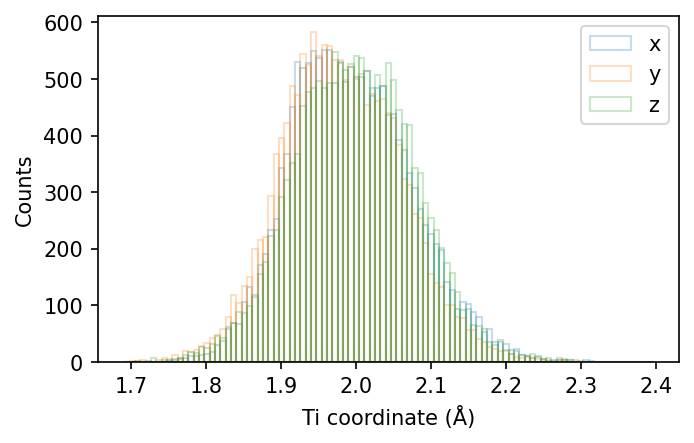

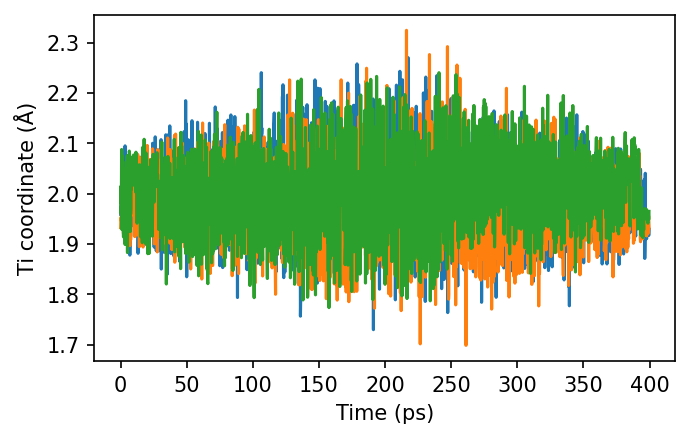

In [25]:
skipinds = 0
all_frac_in_uc = []
all_pos_in_uc = []

Tiinds = [ai for ai, ele in enumerate(mdtraj[0].symbols) if ele == "Ti"]

supercell_mat = np.diag(3*[Nuc])

start_frac_positions = mdtraj[0].get_scaled_positions()
for atoms in mdtraj[1:]:
    #positions = atoms.get_positions()
    effective_uc = np.linalg.inv(supercell_mat) @ atoms.cell

    frac_positions = atoms[Tiinds].get_scaled_positions(wrap=False) # [Tiinds, :]
    frac_in_uc = (frac_positions @ supercell_mat.T) % 1.0

    all_frac_in_uc.append(frac_in_uc)
    all_pos_in_uc.append(frac_in_uc @ effective_uc)

all_frac_in_uc = np.array(all_frac_in_uc)
all_pos_in_uc = np.array(all_pos_in_uc)

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
min_val = min(all_pos_in_uc[skipinds:,].flatten())
max_val = max(all_pos_in_uc[skipinds:,].flatten())
bins = np.linspace(min_val, max_val, num=100)
ax.hist(all_pos_in_uc[skipinds:,:,0].flatten(), alpha=0.25, bins=bins, facecolor="none", edgecolor="tab:blue", label="x")
ax.hist(all_pos_in_uc[skipinds:,:,1].flatten(), alpha=0.25, bins=bins, facecolor="none", edgecolor="tab:orange", label="y")
ax.hist(all_pos_in_uc[skipinds:,:,2].flatten(), alpha=0.25, bins=bins, facecolor="none", edgecolor="tab:green", label="z")
ax.set_xlabel("Ti coordinate (Å)")
ax.set_ylabel("Counts")
ax.legend()

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
tstep = dt * dump * np.arange(all_pos_in_uc.shape[0])
ax.plot(tstep[skipinds:]/1e3, all_pos_in_uc[skipinds:,1,0].flatten(), color="tab:blue")
ax.plot(tstep[skipinds:]/1e3, all_pos_in_uc[skipinds:,1,1].flatten(), color="tab:orange")
ax.plot(tstep[skipinds:]/1e3, all_pos_in_uc[skipinds:,1,2].flatten(), color="tab:green")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Ti coordinate (Å)")

# Plot probability distribution of Ti atoms (folded back into unit cell)

ChatGPT did most here (check could be good)

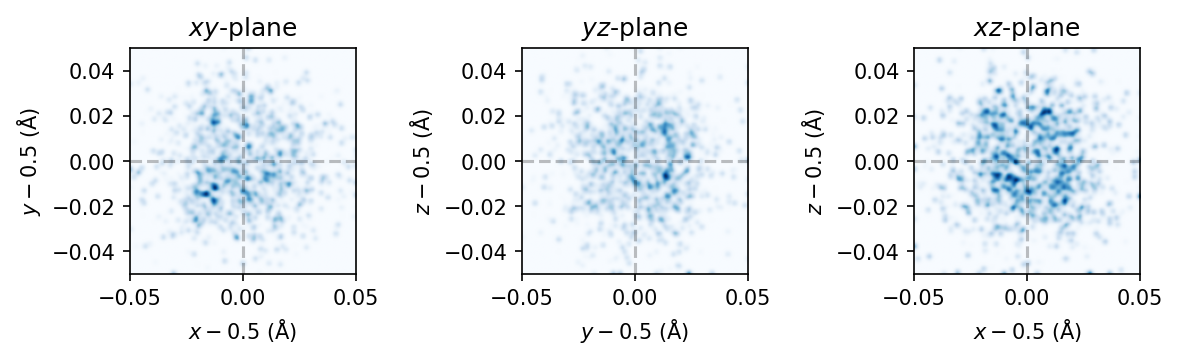

In [32]:
from scipy.ndimage import gaussian_filter

f = all_frac_in_uc.reshape(-1, 3)

center = np.array([0.5, 0.5, 0.5])
delta = 0.05

df = f - center
df -= np.round(df)

nx, ny, nz = 200, 200, 200

scaled = (df + delta) / (2 * delta)

indices = (scaled * [nx, ny, nz]).astype(int)
indices = np.clip(indices, 0, [nx-1, ny-1, nz-1])

density = np.zeros((nx, ny, nz))
for ix, iy, iz in indices:
    density[ix, iy, iz] += 1

density = gaussian_filter(density, sigma=2.0)

if density.sum() > 0:
    density /= density.sum()

fig, axes = plt.subplots(ncols = 3, figsize=(8, 4), dpi=150)
im = axes[0].imshow(density[:, :, nz // 2], origin="lower",
               extent=[-delta, delta, -delta, delta], cmap="Blues")
im = axes[1].imshow(density[nx // 2, :, :], origin="lower",
               extent=[-delta, delta, -delta, delta], cmap="Blues")
im = axes[2].imshow(density[:, ny // 2, :], origin="lower",
               extent=[-delta, delta, -delta, delta], cmap="Blues")

axes[0].set_title(r"$xy$-plane")
axes[1].set_title(r"$yz$-plane")
axes[2].set_title(r"$xz$-plane")
axes[0].set_xlabel(r"$x - 0.5$ (Å)")
axes[0].set_ylabel(r"$y - 0.5$ (Å)")
axes[1].set_xlabel(r"$y - 0.5$ (Å)")
axes[1].set_ylabel(r"$z - 0.5$ (Å)")
axes[2].set_xlabel(r"$x - 0.5$ (Å)")
axes[2].set_ylabel(r"$z - 0.5$ (Å)")

for ax in axes:
    ax.axhline(0, color="k", alpha=0.25, ls="--")
    ax.axvline(0, color="k", alpha=0.25, ls="--")
fig.tight_layout()

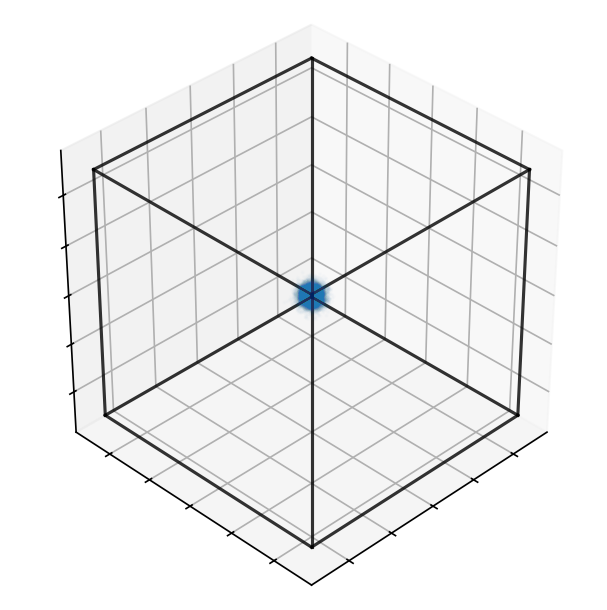

In [ ]:
# 3D plot of density
fig = plt.figure(figsize=(6, 5), dpi=150)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[:,0], df[:,1], df[:,2], alpha=0.01, s=1, color="tab:blue")
# Draw a 3D box representing the unit cell
r = [-0.5, 0.5]
from itertools import product, combinations
for s, e in combinations(np.array(list(product(r, r, r))), 2):
    if np.sum(np.abs(s-e)) == r[1] - r[0]:
        ax.plot([s[0], e[0]], [s[1], e[1]], [s[2], e[2]], color="k", ls="-", alpha=0.8)
# Set equal aspect ratio
ax.set_aspect('equal')
# Rotate the view
ax.view_init(elev=35, azim=45)
#ax.set_xlabel(r"$x - 0.5$ (Å)")
#ax.set_ylabel(r"$y - 0.5$ (Å)")
#ax.set_zlabel(r"$z - 0.5$ (Å)")
# Remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
# Remove ticks but keep the grid

#ax.grid(False)
#ax.set_axis_off()
plt.show()

In [19]:
import pyvista as pv

grid = pv.ImageData()
grid.dimensions = np.array(density.shape) + 1
grid.spacing = (1/nx, 1/ny, 1/nz)
grid.origin = (0, 0, 0)

grid.cell_data["density"] = density.flatten(order="F")

plotter = pv.Plotter()
plotter.add_volume(grid, opacity="sigmoid")
plotter.show()

ModuleNotFoundError: No module named 'pyvista'